# Análisis Inferencial: Transporte Privado vs Público en Madrid

---

## ¿Qué es el análisis inferencial?

El análisis **descriptivo** resume lo que observamos en nuestra muestra. 
El análisis **inferencial** va un paso más allá: usa esa muestra para sacar conclusiones sobre la **población general**, cuantificando la incertidumbre con probabilidades.

En este proyecto responderemos con rigor estadístico a cuatro preguntas:

| Pregunta | Herramienta |
|---|---|
| ¿Cuál es el rango probable del tiempo medio real de cada modo? | **Intervalos de Confianza** |
| ¿El transporte público tarda significativamente más que el privado? | **Contraste de Hipótesis (T de Student Pareada)** |
| ¿Varía la diferencia según la franja horaria? | **IC + contraste por franja** |
| ¿Varía la diferencia según la distancia del trayecto? | **IC + contraste por distancia** |

---

**Fuente de datos:** `combinado1.csv` — emparejado por ruta (origen-destino) y hora de salida.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ModuleNotFoundError: No module named 'pandas'

---
## 1. Preparación del dataset pareado

Para que la comparación sea justa, cada observación DRIVE debe tener su observación TRANSIT **en la misma ruta y a la misma hora**. Esto se llama **emparejamiento** y es el requisito fundamental de la t de Student pareada.

- **Tiempo DRIVE:** `duracion_con_trafico_min` (tiempo real con tráfico)
- **Tiempo TRANSIT:** `duracion_sin_trafico_min` (tiempo de tránsito programado)

El emparejamiento se hace con un `merge` por `origen + destino + hora_salida`.

In [ ]:
df = pd.read_csv('combinado1.csv')

drive = (
 df[df['modo_transporte'] == 'DRIVE']
 [['origen', 'destino', 'hora_salida', 'duracion_con_trafico_min']]
 .rename(columns={'duracion_con_trafico_min': 'tiempo_drive'})
)

transit = (
 df[df['modo_transporte'] == 'TRANSIT']
 [['origen', 'destino', 'hora_salida', 'duracion_sin_trafico_min']]
 .rename(columns={'duracion_sin_trafico_min': 'tiempo_transit'})
)

pareado = (
 pd.merge(drive, transit, on=['origen', 'destino', 'hora_salida'])
 .dropna(subset=['tiempo_drive', 'tiempo_transit'])
 .reset_index(drop=True)
)
pareado['diferencia'] = pareado['tiempo_transit'] - pareado['tiempo_drive']

print(f"Observaciones pareadas totales : {len(pareado)}")
print(f"Rutas únicas (origen-destino) : {pareado.groupby(['origen','destino']).ngroups}")
print(f"Horas únicas de consulta : {pareado['hora_salida'].nunique()}")
print(f"Valores nulos en tiempo_drive : {pareado['tiempo_drive'].isna().sum()}")
print(f"Valores nulos en tiempo_transit: {pareado['tiempo_transit'].isna().sum()}")

Observaciones pareadas totales : 1391
Rutas únicas (origen-destino)  : 61
Horas únicas de consulta       : 23
Valores nulos en tiempo_drive  : 0
Valores nulos en tiempo_transit: 0


In [ ]:
print("Primeras 8 filas del dataset pareado:")
pareado[['origen', 'destino', 'hora_salida', 'tiempo_drive', 'tiempo_transit', 'diferencia']].head(8)

Primeras 8 filas del dataset pareado:


,origen,destino,hora_salida,tiempo_drive,tiempo_transit,diferencia
0,"Puerta del Sol, Madrid","Aeropuerto Adolfo Suárez Madrid-Barajas, Madrid",01:00,20.8,41.9,21.1
1,"Puerta del Sol, Madrid","Estación de Atocha, Madrid",01:00,10.6,11.2,0.6
2,"Puerta del Sol, Madrid","Estación de Chamartín, Madrid",01:00,21.3,28.4,7.1
3,"Puerta del Sol, Madrid","Plaza de Castilla, Madrid",01:00,20.6,22.4,1.8
4,"Puerta del Sol, Madrid","Vallecas, Madrid",01:00,18.8,40.0,21.2
5,"Puerta del Sol, Madrid","Moncloa, Madrid",01:00,16.0,55.0,39.0
6,"Puerta del Sol, Madrid","Cuatro Caminos, Madrid",01:00,16.4,18.2,1.8
7,"Gran Vía, Madrid","Estadio Santiago Bernabéu, Madrid",01:00,9.6,21.4,11.8


---
## 2. Datos descriptivos del dataset pareado

Antes de aplicar cualquier test inferencial, conviene ver cómo se distribuyen los datos.
Implementamos los estadísticos **manualmente** para mostrar los cálculos subyacentes.

In [ ]:
def media(x):
 return sum(x) / len(x)

def cuasivarianza(x):
 m = media(x)
 return sum((xi - m) ** 2 for xi in x) / (len(x) - 1)

def desv_tipica(x):
 return cuasivarianza(x) ** 0.5

def mediana(x):
 s = sorted(x)
 n = len(s)
 return (s[n // 2 - 1] + s[n // 2]) / 2 if n % 2 == 0 else s[n // 2]

drive_vals = pareado['tiempo_drive'].tolist()
transit_vals = pareado['tiempo_transit'].tolist()
dif_vals = pareado['diferencia'].tolist()

resumen = pd.DataFrame({
 'Estadístico': ['N', 'Media (min)', 'Mediana (min)', 'Desv. Típica', 'Mínimo', 'Máximo'],
 'DRIVE (con tráfico)': [
 len(drive_vals),
 round(media(drive_vals), 2),
 round(mediana(drive_vals), 2),
 round(desv_tipica(drive_vals), 2),
 round(min(drive_vals), 2),
 round(max(drive_vals), 2)
 ],
 'TRANSIT': [
 len(transit_vals),
 round(media(transit_vals), 2),
 round(mediana(transit_vals), 2),
 round(desv_tipica(transit_vals), 2),
 round(min(transit_vals), 2),
 round(max(transit_vals), 2)
 ],
 'Diferencia (T - D)': [
 len(dif_vals),
 round(media(dif_vals), 2),
 round(mediana(dif_vals), 2),
 round(desv_tipica(dif_vals), 2),
 round(min(dif_vals), 2),
 round(max(dif_vals), 2)
 ]
}).set_index('Estadístico')

print("DATOS DESCRIPTIVOS DEL DATASET PAREADO")
print("(Diferencia = tiempo_transit − tiempo_drive)")
print()
resumen

DATOS DESCRIPTIVOS DEL DATASET PAREADO
(Diferencia = tiempo_transit − tiempo_drive)



,DRIVE (con tráfico),TRANSIT,Diferencia (T - D)
Estadístico,,,
N,1391.00,1391.00,1391.00
Media (min),64.62,72.67,8.05
Mediana (min),23.90,45.20,12.30
Desv. Típica,87.34,75.02,54.55
Mínimo,5.00,9.00,-194.60
Máximo,380.20,561.20,440.30


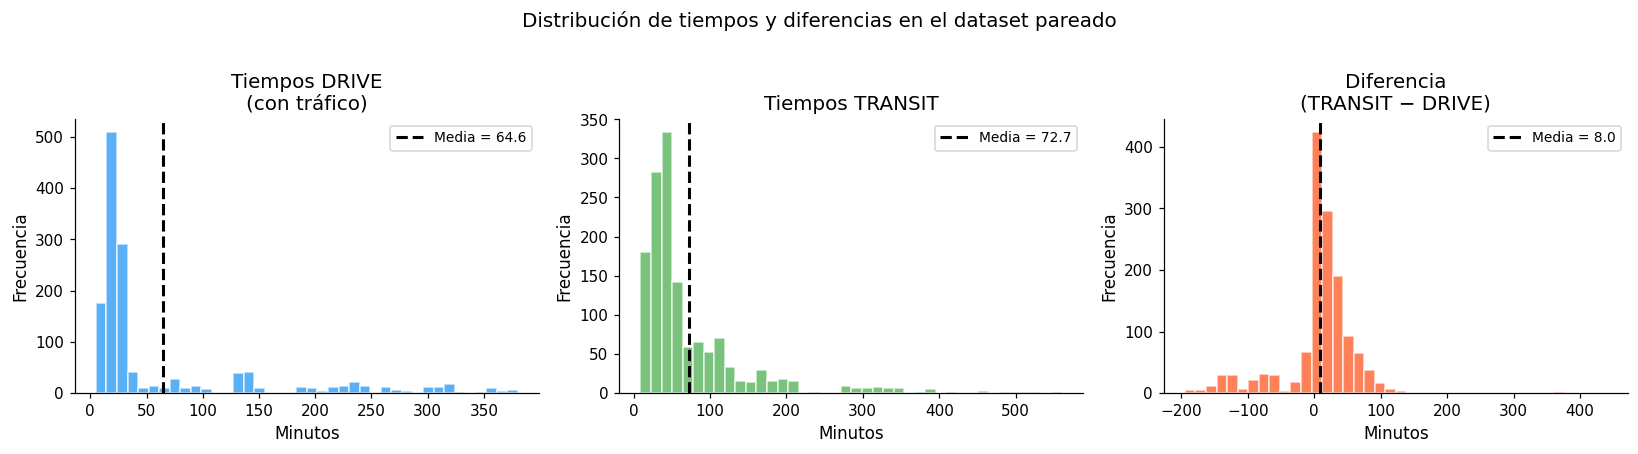


Observación clave: la diferencia media es 8.05 min.
Un valor positivo significa que TRANSIT tarda más que DRIVE en promedio.
Pero ¿es esta diferencia estadísticamente significativa o podría ser azar?
Eso lo responde el contraste de hipótesis (Sección 5).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colores = ['#2196F3', '#4CAF50', '#FF5722']
datos = [drive_vals, transit_vals, dif_vals]
titulos = ['Tiempos DRIVE\n(con tráfico)', 'Tiempos TRANSIT', 'Diferencia\n(TRANSIT − DRIVE)']

for ax, d, titulo, color in zip(axes, datos, titulos, colores):
 ax.hist(d, bins=40, color=color, alpha=0.75, edgecolor='white')
 ax.axvline(media(d), color='black', linewidth=2, linestyle='--', label=f'Media = {media(d):.1f}')
 ax.set_title(titulo)
 ax.set_xlabel('Minutos')
 ax.set_ylabel('Frecuencia')
 ax.legend(fontsize=9)

plt.suptitle('Distribución de tiempos y diferencias en el dataset pareado', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nObservación clave: la diferencia media es {media(dif_vals):.2f} min.")
print("Un valor positivo significa que TRANSIT tarda más que DRIVE en promedio.")
print("Pero ¿es esta diferencia estadísticamente significativa o podría ser azar?")
print("Eso lo responde el contraste de hipótesis (Sección 5).")

---
## 3. Verificación de supuestos

La t de Student pareada asume que las **diferencias** $d_i = \text{TRANSIT}_i - \text{DRIVE}_i$ siguen una distribución **normal** (o que la muestra es suficientemente grande para que el Teorema Central del Límite actúe).

Verificamos la forma de la distribución mediante el **histograma de las diferencias** con curva normal superpuesta.

### Varianza desconocida → distribución t de Student

Como no conocemos la varianza real de la población, la estimamos con la **cuasivarianza muestral**:

$$\hat{S}^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n - 1}$$

Cuando la varianza es **desconocida**, el estadístico de contraste sigue una distribución $t_{n-1}$ (T de Student con $n-1$ grados de libertad), no una Normal estándar.

| Varianza | Estadístico | Distribución |
|---|---|---|
| **Conocida** ($\sigma^2$) | $Z = \dfrac{\bar{x} - \mu_0}{\sigma/\sqrt{n}}$ | $N(0,1)$ |
| **Desconocida** (nuestro caso) | $t = \dfrac{\bar{x} - \mu_0}{\hat{S}/\sqrt{n}}$ | $t_{n-1}$ |

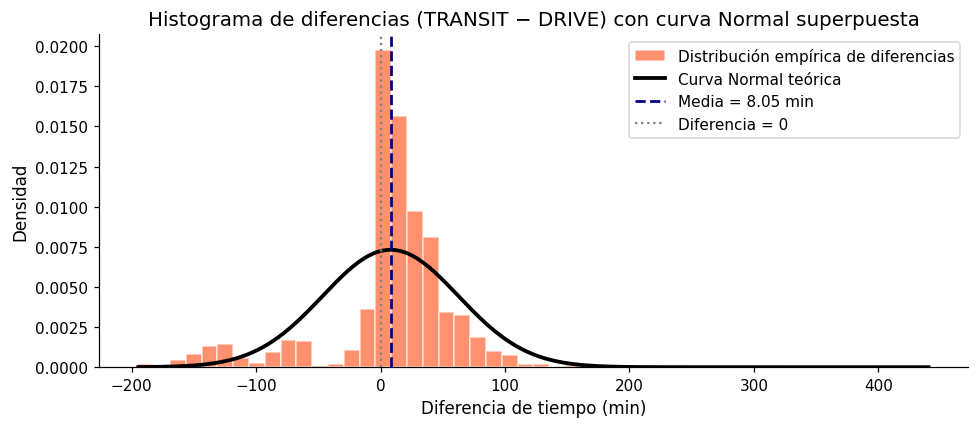

In [ ]:
d = np.array(dif_vals)
mu_d = d.mean()
sig_d = d.std(ddof=1)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(d, bins=50, density=True, color='#FF5722', alpha=0.65,
 edgecolor='white', label='Distribución empírica de diferencias')

x = np.linspace(d.min(), d.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu_d, sig_d),
 color='black', linewidth=2.5, label='Curva Normal teórica')

ax.axvline(mu_d, color='navy', linestyle='--', linewidth=1.8, label=f'Media = {mu_d:.2f} min')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Diferencia = 0')

ax.set_title('Histograma de diferencias (TRANSIT − DRIVE) con curva Normal superpuesta')
ax.set_xlabel('Diferencia de tiempo (min)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

### Justificación: Teorema Central del Límite (TCL)

El **Teorema Central del Límite (TCL)** garantiza que:

> *Cuando el tamaño muestral es suficientemente grande (generalmente $n \geq 30$), la distribución de la media muestral se aproxima a una Normal, independientemente de la distribución original de los datos.*

Con **n = 1391 pares**, el TCL garantiza que nuestras inferencias son válidas aunque las diferencias individuales no sigan exactamente una distribución normal. 
La t de Student con $n - 1 = 1390$ grados de libertad es prácticamente equivalente a una distribución Normal estándar.

---
## 4. Intervalos de Confianza al 95%

### ¿Qué es un intervalo de confianza?

Un **intervalo de confianza al 95%** es un rango de valores que, si repitiéramos el estudio muchas veces, contendría el verdadero parámetro poblacional en el **95% de los casos**.

**No significa** que haya un 95% de probabilidad de que el parámetro esté en ese intervalo concreto el parámetro es fijo, lo que varía es el intervalo de muestra a muestra.

### Varianza conocida vs varianza desconocida

| Situación | Estadístico | Fórmula del IC |
|---|---|---|
| Varianza **conocida** ($\sigma^2$) | $Z \sim N(0,1)$ | $\bar{x} \pm z_{\alpha/2} \cdot \dfrac{\sigma}{\sqrt{n}}$ |
| Varianza **desconocida** (nuestro caso) | $t_{n-1}$ | $\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \dfrac{\hat{S}}{\sqrt{n}}$ |

En nuestro caso la varianza poblacional es **desconocida**, por lo que estimamos $\sigma$ mediante la **cuasivarianza muestral** $\hat{S}^2 = \frac{\sum(x_i-\bar{x})^2}{n-1}$ y usamos la distribución $t_{n-1}$.

### Fórmula aplicada

$$IC_{95\%} = \bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{\hat{S}}{\sqrt{n}}$$

Donde:
- $\bar{x}$ : media muestral
- $\hat{S}$ : desviación típica muestral (raíz de la cuasivarianza, divide por $n-1$)
- $n$ : número de observaciones
- $t_{\alpha/2,\, n-1}$ : valor crítico de la distribución t con $n-1$ grados de libertad
- $\dfrac{\hat{S}}{\sqrt{n}}$ : **error estándar de la media**

In [ ]:
alpha = 0.05 # nivel de significación → confianza del 95%

def intervalo_confianza(valores, alpha=0.05, nombre=''):
 n = len(valores)
 xbar = np.mean(valores)
 s = np.std(valores, ddof=1)
 ee = s / np.sqrt(n) # error estándar
 gl = n - 1 # grados de libertad
 t_c = stats.t.ppf(1 - alpha / 2, df=gl) # valor crítico
 margen = t_c * ee
 ic_inf = xbar - margen
 ic_sup = xbar + margen

 print(f"── {nombre} ──")
 print(f" n = {n}")
 print(f" Media muestral = {xbar:.4f} min")
 print(f" Desv. típica = {s:.4f} min")
 print(f" Error estándar = {ee:.4f} min")
 print(f" Grados de libertad = {gl}")
 print(f" Valor crítico t = ±{t_c:.4f}")
 print(f" Margen de error = {margen:.4f} min")
 print(f" IC 95% = [{ic_inf:.4f}, {ic_sup:.4f}] min")
 print()
 return ic_inf, xbar, ic_sup

ic_drive_inf, mu_drive, ic_drive_sup = intervalo_confianza(drive_vals, nombre='IC para μ_DRIVE')
ic_transit_inf, mu_transit, ic_transit_sup = intervalo_confianza(transit_vals, nombre='IC para μ_TRANSIT')
ic_dif_inf, mu_dif, ic_dif_sup = intervalo_confianza(dif_vals, nombre='IC para μ_diferencia (TRANSIT − DRIVE)')

── IC para μ_DRIVE ──
  n                  = 1391
  Media muestral     = 64.6237 min
  Desv. típica       = 87.3362 min
  Error estándar     = 2.3417 min
  Grados de libertad = 1390
  Valor crítico t    = ±1.9617
  Margen de error    = 4.5936 min
  IC 95%             = [60.0300, 69.2173] min

── IC para μ_TRANSIT ──
  n                  = 1391
  Media muestral     = 72.6731 min
  Desv. típica       = 75.0185 min
  Error estándar     = 2.0114 min
  Grados de libertad = 1390
  Valor crítico t    = ±1.9617
  Margen de error    = 3.9458 min
  IC 95%             = [68.7273, 76.6189] min

── IC para μ_diferencia (TRANSIT − DRIVE) ──
  n                  = 1391
  Media muestral     = 8.0495 min
  Desv. típica       = 54.5489 min
  Error estándar     = 1.4626 min
  Grados de libertad = 1390
  Valor crítico t    = ±1.9617
  Margen de error    = 2.8691 min
  IC 95%             = [5.1803, 10.9186] min



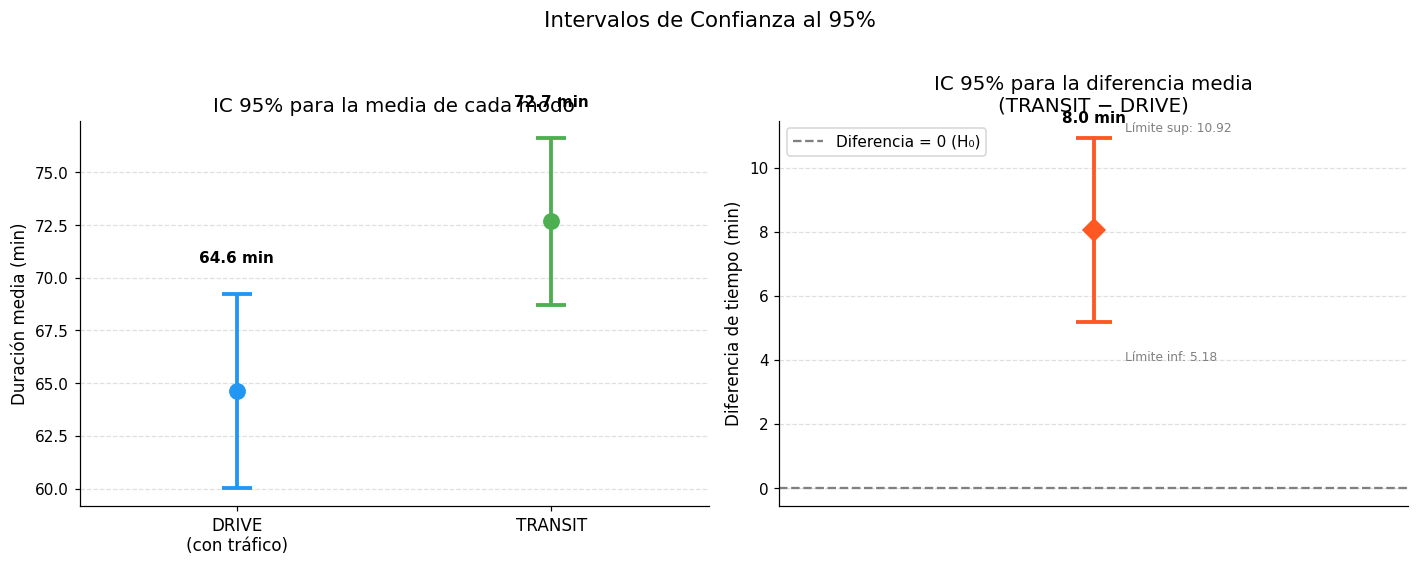

INTERPRETACIÓN:
  Con un 95% de confianza, el tiempo medio real en DRIVE está entre 60.03 y 69.22 min.
  Con un 95% de confianza, el tiempo medio real en TRANSIT está entre 68.73 y 76.62 min.
  Con un 95% de confianza, el transporte público tarda entre 5.18 y 10.92 min más que el privado.
  → El intervalo NO contiene el 0: hay evidencia de diferencia real entre modos.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico izquierdo: IC para DRIVE y TRANSIT ---
ax = axes[0]
etiquetas = ['DRIVE\n(con tráfico)', 'TRANSIT']
medias = [mu_drive, mu_transit]
inf = [mu_drive - ic_drive_inf, mu_transit - ic_transit_inf]
sup = [ic_drive_sup - mu_drive, ic_transit_sup - mu_transit]
colores_ic = ['#2196F3', '#4CAF50']

for i, (et, med, lo, hi, col) in enumerate(zip(etiquetas, medias, inf, sup, colores_ic)):
 ax.errorbar(i, med, yerr=[[lo], [hi]], fmt='o', color=col,
 markersize=10, capsize=10, capthick=2.5, linewidth=2.5)
 ax.text(i, med + hi + 1.5, f'{med:.1f} min', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylabel('Duración media (min)')
ax.set_title('IC 95% para la media de cada modo')
ax.set_xlim(-0.5, 1.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Gráfico derecho: IC para la diferencia ---
ax2 = axes[1]
lo_dif = mu_dif - ic_dif_inf
hi_dif = ic_dif_sup - mu_dif
ax2.errorbar(0, mu_dif, yerr=[[lo_dif], [hi_dif]], fmt='D', color='#FF5722',
 markersize=10, capsize=12, capthick=2.5, linewidth=2.5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Diferencia = 0 (H₀)')
ax2.text(0, mu_dif + hi_dif + 0.5, f'{mu_dif:.1f} min', ha='center', fontsize=10, fontweight='bold')
ax2.text(0.05, ic_dif_sup + 0.2, f'Límite sup: {ic_dif_sup:.2f}', fontsize=8, color='gray')
ax2.text(0.05, ic_dif_inf - 1.2, f'Límite inf: {ic_dif_inf:.2f}', fontsize=8, color='gray')
ax2.set_xticks([])
ax2.set_ylabel('Diferencia de tiempo (min)')
ax2.set_title('IC 95% para la diferencia media\n(TRANSIT − DRIVE)')
ax2.set_xlim(-0.5, 0.5)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Intervalos de Confianza al 95%', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN:")
print(f" Con un 95% de confianza, el tiempo medio real en DRIVE está entre {ic_drive_inf:.2f} y {ic_drive_sup:.2f} min.")
print(f" Con un 95% de confianza, el tiempo medio real en TRANSIT está entre {ic_transit_inf:.2f} y {ic_transit_sup:.2f} min.")
print(f" Con un 95% de confianza, el transporte público tarda entre {ic_dif_inf:.2f} y {ic_dif_sup:.2f} min más que el privado.")
if ic_dif_inf > 0:
 print(" → El intervalo NO contiene el 0: hay evidencia de diferencia real entre modos.")
else:
 print(" → El intervalo contiene el 0: no hay evidencia suficiente de diferencia real.")

### Conclusion — Seccion 4: Intervalos de Confianza

| Parametro | IC 95 % | Contiene el 0 |
|---|---|---|
| $\mu_{\text{DRIVE}}$ | [60,03 ; 69,22] min | — |
| $\mu_{\text{TRANSIT}}$ | [68,73 ; 76,62] min | — |
| **$\mu_{\text{dif}}$ (T − D)** | **[5,18 ; 10,92] min** | **No → diferencia real** |

El IC de la diferencia **no contiene el 0**: hay evidencia estadistica de que el transporte publico tarda mas que el privado.

### Interpretación de los intervalos de confianza

Los tres intervalos obtenidos nos permiten situar los tiempos medios reales en la población madrileña con un margen de error controlado:

- **Transporte privado (DRIVE):** el tiempo medio se encuentra con un 95 % de confianza entre **60,0 y 69,2 minutos**. La amplitud del intervalo refleja la variabilidad del tráfico en función de la ruta y la hora.
- **Transporte público (TRANSIT):** el intervalo correspondiente es **[68,7 ; 76,6] minutos**, ligeramente superior al del privado en todo su recorrido.
- **Diferencia (TRANSIT − DRIVE):** el intervalo **[5,18 ; 10,92] minutos** es el más relevante a efectos prácticos. Al no contener el valor 0, descarta estadísticamente la hipótesis de que ambos modos tarden lo mismo: el transporte público emplea entre 5 y 11 minutos más en promedio.

> **Nota metodológica:** como la varianza poblacional es desconocida, se usa la distribución $t_{n-1}$ con cuasivarianza muestral. Con $n = 1\,391$ pares el valor crítico $t = 1{,}962$ es prácticamente equivalente al $z = 1{,}960$ de la Normal estándar.

---
## 5. Contraste de Hipótesis: T de Student Pareada

### ¿Qué queremos demostrar?

Queremos saber si la diferencia media observada ($\bar{d}$) es suficientemente grande como para concluir que **no es producto del azar**.

### Planteamiento de hipótesis

| Hipótesis | Significado |
|---|---|
| $H_0: \mu_d = 0$ | Los dos modos tardan lo mismo en promedio |
| $H_1: \mu_d > 0$ | El transporte público tarda **más** que el privado |

### Contraste unilateral vs bilateral

- **Bilateral** ($H_1: \mu_d \neq 0$): detecta diferencia en cualquier dirección. Región crítica en ambas colas: $|t| > t_{\alpha/2,\, n-1}$.
- **Unilateral derecho** ($H_1: \mu_d > 0$): solo detecta si TRANSIT es más lento. Región crítica en la cola derecha: $t > t_{\alpha,\, n-1}$.

Usamos un contraste **unilateral derecho** porque la hipótesis es direccional: esperamos que TRANSIT tarde más, no solo que sea diferente.

### Estadístico de prueba (varianza desconocida → t de Student)

$$t = \frac{\bar{d}}{\hat{S}_d / \sqrt{n}}$$

Donde $\bar{d}$ es la media de las diferencias y $\hat{S}_d$ su desviación típica muestral (cuasivarianza). 
Bajo $H_0$, este estadístico sigue una distribución $t$ con $n - 1$ grados de libertad.

### Regla de decisión

- Si $t > t_{\alpha,\, n-1}$ → **Rechazamos $H_0$** (el estadístico cae en la **región crítica**)
- Si $p\text{-valor} < \alpha = 0.05$ → **Rechazamos $H_0$**
- En caso contrario: **no se rechaza $H_0$** — la hipótesis nula nunca se «acepta», solo se carece de evidencia para rechazarla

### Errores posibles en la decisión

| Error | Definición | Probabilidad |
|---|---|---|
| **Error de tipo I** ($\alpha$) | Rechazar $H_0$ siendo verdadera (falso positivo) | $\alpha = 0.05$ (fijado) |
| **Error de tipo II** ($\beta$) | No rechazar $H_0$ siendo falsa (falso negativo) | Depende de $n$ y del efecto real |

In [ ]:
# ── Cálculo manual del estadístico t ──────────────────────────────────────────
d_arr = np.array(dif_vals)

n_pares = len(d_arr)
d_bar = d_arr.mean() # media de las diferencias
s_d = d_arr.std(ddof=1) # desv. típica muestral de las diferencias
ee_d = s_d / np.sqrt(n_pares) # error estándar de la media de diferencias
gl = n_pares - 1 # grados de libertad

t_obs = d_bar / ee_d # estadístico t observado

# Valor crítico para contraste unilateral derecho (α = 0.05)
alpha = 0.05
t_critico = stats.t.ppf(1 - alpha, df=gl)

# p-valor unilateral (P(T > t_obs))
p_unilateral = stats.t.sf(t_obs, df=gl)

# p-valor bilateral (P(|T| > |t_obs|))
p_bilateral = 2 * stats.t.sf(abs(t_obs), df=gl)

print("═" * 55)
print("CONTRASTE T DE STUDENT PAREADA — CÁLCULO MANUAL")
print("═" * 55)
print(f" n (pares) = {n_pares}")
print(f" Grados de libertad = {gl}")
print(f" Media de diferencias = {d_bar:.4f} min")
print(f" Desv. típica (s_d) = {s_d:.4f} min")
print(f" Error estándar = {ee_d:.4f} min")
print()
print(f" t observado = {d_bar:.4f} / {ee_d:.4f} = {t_obs:.4f}")
print(f" t crítico (α=0.05, →) = {t_critico:.4f}")
print()
print(f" p-valor unilateral = {p_unilateral:.2e}")
print(f" p-valor bilateral = {p_bilateral:.2e}")
print("═" * 55)
print()
if t_obs > t_critico:
 print(f" Decisión: t_obs ({t_obs:.2f}) > t_crítico ({t_critico:.2f})")
 print(" → Se RECHAZA H₀ al nivel de significación α = 0.05")
 print(" → El transporte público tarda significativamente más que el privado.")
else:
 print(f" Decisión: t_obs ({t_obs:.2f}) ≤ t_crítico ({t_critico:.2f})")
 print(" → No se rechaza H₀ al nivel de significación α = 0.05")

═══════════════════════════════════════════════════════
CONTRASTE T DE STUDENT PAREADA — CÁLCULO MANUAL
═══════════════════════════════════════════════════════
  n (pares)              = 1391
  Grados de libertad     = 1390
  Media de diferencias   = 8.0495 min
  Desv. típica (s_d)     = 54.5489 min
  Error estándar         = 1.4626 min

  t observado            = 8.0495 / 1.4626 = 5.5036
  t crítico (α=0.05, →)  = 1.6460

  p-valor unilateral     = 2.21e-08
  p-valor bilateral      = 4.43e-08
═══════════════════════════════════════════════════════

  Decisión: t_obs (5.50) > t_crítico (1.65)
  → Se RECHAZA H₀ al nivel de significación α = 0.05
  → El transporte público tarda significativamente más que el privado.


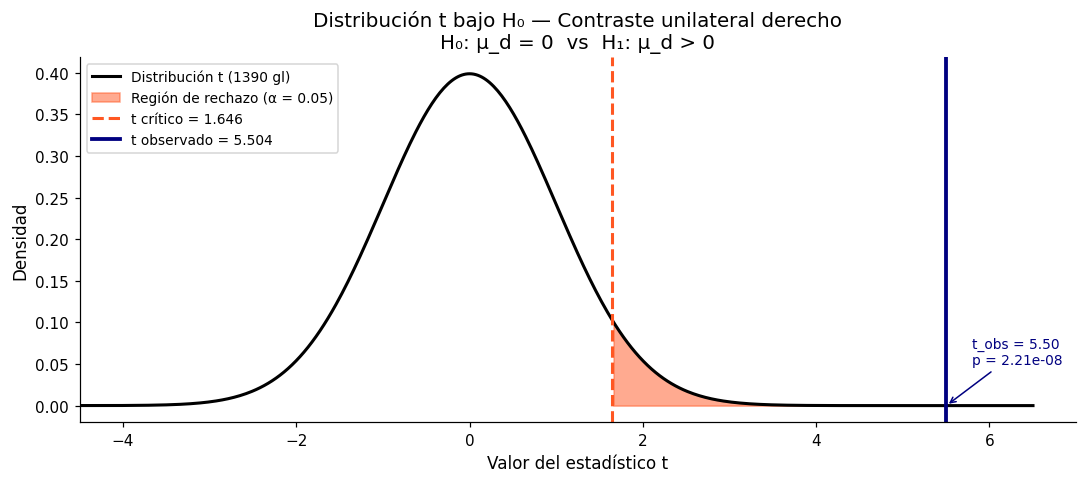

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Rango de la distribución t
x = np.linspace(-5, max(t_obs + 1, 5), 500)
y = stats.t.pdf(x, df=gl)

ax.plot(x, y, color='black', linewidth=2, label='Distribución t (1390 gl)')

# Región de rechazo (cola derecha)
x_rechazo = x[x >= t_critico]
ax.fill_between(x_rechazo, stats.t.pdf(x_rechazo, df=gl),
 color='#FF5722', alpha=0.5, label=f'Región de rechazo (α = {alpha})')

# Línea del valor crítico
ax.axvline(t_critico, color='#FF5722', linestyle='--', linewidth=2,
 label=f't crítico = {t_critico:.3f}')

# Estadístico observado
ax.axvline(t_obs, color='navy', linestyle='-', linewidth=2.5,
 label=f't observado = {t_obs:.3f}')
ax.annotate(f't_obs = {t_obs:.2f}\np = {p_unilateral:.2e}',
 xy=(t_obs, stats.t.pdf(t_obs, df=gl)),
 xytext=(t_obs + 0.3, stats.t.pdf(t_obs, df=gl) + 0.05),
 fontsize=9, color='navy',
 arrowprops=dict(arrowstyle='->', color='navy'))

ax.set_xlim(-4.5, max(t_obs + 1.5, 5))
ax.set_xlabel('Valor del estadístico t')
ax.set_ylabel('Densidad')
ax.set_title('Distribución t bajo H₀ — Contraste unilateral derecho\n'
 'H₀: μ_d = 0 vs H₁: μ_d > 0')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Verificación con scipy (resultado debe coincidir) ─────────────────────────
t_scipy, p_scipy_bilateral = stats.ttest_rel(pareado['tiempo_transit'], pareado['tiempo_drive'])
p_scipy_unilateral = p_scipy_bilateral / 2 # convertir a unilateral

print("VERIFICACIÓN CON scipy.stats.ttest_rel")
print(f" t (scipy) = {t_scipy:.4f} ← debe coincidir con {t_obs:.4f}")
print(f" p bilateral (scipy) = {p_scipy_bilateral:.2e}")
print(f" p unilateral (scipy) = {p_scipy_unilateral:.2e}")

VERIFICACIÓN CON scipy.stats.ttest_rel
  t (scipy)              = 5.5036  ← debe coincidir con 5.5036
  p bilateral (scipy)    = 4.43e-08
  p unilateral (scipy)   = 2.21e-08


### Interpretación del contraste

El **p-valor** es la probabilidad de obtener un estadístico tan extremo o más que el observado, **asumiendo que $H_0$ es verdadera** (es decir, asumiendo que los modos tardan lo mismo).

- Si $p < 0.05$: la diferencia observada sería muy improbable bajo $H_0$ → rechazamos $H_0$.
- Si $p \geq 0.05$: la diferencia podría deberse al azar → no rechazamos $H_0$.

> **Importante:** rechazar $H_0$ no prueba que $H_1$ sea verdadera, sino que los datos son inconsistentes con $H_0$ al nivel de significación elegido.

### Conclusion — Seccion 5: Contraste de Hipotesis (T de Student Pareada)

| Elemento | Valor |
|---|---|
| $t$ observado | 5,5036 |
| $t$ critico ($\alpha = 0{,}05$, unilateral derecho) | 1,6460 |
| p-valor | $2{,}21 \times 10^{-8}$ |
| **Decision** | **Se RECHAZA $H_0$** |

El transporte publico tarda en promedio **8,0 min mas** que el privado — IC 95 %: [5,18 ; 10,92] min.

| Error | Definicion |
|---|---|
| **Tipo I** ($\alpha = 0{,}05$) | Rechazar $H_0$ siendo verdadera (falso positivo) |
| **Tipo II** ($\beta$) | No rechazar $H_0$ siendo falsa (falso negativo) |

### Interpretación del resultado del contraste

El estadístico $t_{obs} = 5{,}50$ supera con amplio margen el valor crítico $t_{crit} = 1{,}646$, situándose bien dentro de la región de rechazo. El p-valor ($2{,}21 \times 10^{-8}$) es prácticamente nulo: la probabilidad de observar una diferencia tan grande por azar, si los modos tardaran lo mismo, es insignificante.

| Elemento | Valor | Significado |
|---|---|---|
| $t_{obs}$ | 5,50 | Estadístico calculado sobre la muestra |
| $t_{crit}$ | 1,646 | Umbral de rechazo ($\alpha = 0{,}05$, unilateral) |
| p-valor | $2{,}21 \times 10^{-8}$ | Probabilidad de este resultado bajo $H_0$ |
| Decisión | **Rechazar $H_0$** | Evidencia estadística muy sólida |

**En términos prácticos**, el transporte público tarda **8,0 minutos más** que el privado en los trayectos analizados, y esta diferencia es estadísticamente significativa. Sin embargo, la significación estadística no implica relevancia práctica uniforme: la magnitud varía notablemente según la franja horaria y la distancia, como muestran los análisis de las secciones 6 y 7.

> El riesgo de **error de tipo I** (concluir que hay diferencia cuando no la hay) está fijado en $\alpha = 0{,}05$. El riesgo de **error de tipo II** (no detectar una diferencia real) disminuye al aumentar el tamaño muestral y la magnitud del efecto, ambos favorables en este estudio.

---
## 6. Análisis por franja horaria

Aplicamos el mismo IC 95% y contraste de hipótesis a cada franja horaria para comprobar si la diferencia entre modos varía a lo largo del día.

| Franja | Horas |
|---|---|
| Madrugada | 00 – 06 h |
| Mañana | 07 – 12 h |
| Tarde | 13 – 18 h |
| Noche | 19 – 23 h |

En cada franja: $H_0: \mu_d = 0$ vs $H_1: \mu_d > 0$ (contraste unilateral derecho, $\alpha = 0.05$, varianza desconocida → $t_{n-1}$).

In [ ]:
def hora_a_franja(h_str):
 h = int(h_str.split(':')[0])
 if h < 7: return 'Madrugada (00-06h)'
 elif h < 13: return 'Manana (07-12h)'
 elif h < 19: return 'Tarde (13-18h)'
 else: return 'Noche (19-23h)'

FRANJAS_ORD = ['Madrugada (00-06h)', 'Manana (07-12h)', 'Tarde (13-18h)', 'Noche (19-23h)']
COLORES_F = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']
ETIQ_F = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
pareado['franja'] = pareado['hora_salida'].apply(hora_a_franja)

alpha_sub = 0.05
filas_f = []
for franja in FRANJAS_ORD:
 d_sub = pareado[pareado['franja'] == franja]['diferencia'].values
 n_sub = len(d_sub)
 dbar = d_sub.mean()
 sd_sub = d_sub.std(ddof=1)
 ee_sub = sd_sub / np.sqrt(n_sub)
 gl_sub = n_sub - 1
 tc_ic = stats.t.ppf(1 - alpha_sub / 2, df=gl_sub)
 ic_i = dbar - tc_ic * ee_sub
 ic_s = dbar + tc_ic * ee_sub
 t_sub = dbar / ee_sub
 tc_t = stats.t.ppf(1 - alpha_sub, df=gl_sub)
 pval = float(stats.t.sf(t_sub, df=gl_sub))
 filas_f.append({
 'Franja': franja,
 'n': n_sub,
 'Media(min)': round(dbar, 2),
 'Sd': round(sd_sub, 2),
 'IC_inf': round(ic_i, 2),
 'IC_sup': round(ic_s, 2),
 't_obs': round(t_sub, 3),
 't_crit': round(tc_t, 3),
 'p_valor': f'{pval:.2e}',
 'Decision': 'Rechaza H0' if t_sub > tc_t else 'No rechaza H0',
 })

df_f = pd.DataFrame(filas_f).set_index('Franja')
df_f.index = ETIQ_F
print('IC 95% Y CONTRASTE POR FRANJA HORARIA')
print(f'H0: mu_d = 0 vs H1: mu_d > 0 (unilateral derecho, alfa={alpha_sub})')
print()
df_f

IC 95% Y CONTRASTE POR FRANJA HORARIA
H0: mu_d = 0  vs  H1: mu_d > 0  (unilateral derecho, alfa=0.05)



,n,Media(min),Sd,IC_inf,IC_sup,t_obs,t_crit,p_valor,Decision
Madrugada,365,12.14,53.70,6.61,17.66,4.317,1.649,1.02e-05,Rechaza H0
Mañana,366,2.70,50.16,-2.45,7.86,1.030,1.649,1.52e-01,No rechaza H0
Tarde,366,-0.25,50.33,-5.42,4.92,-0.095,1.649,5.38e-01,No rechaza H0
Noche,294,19.97,62.91,12.75,27.19,5.442,1.650,5.57e-08,Rechaza H0


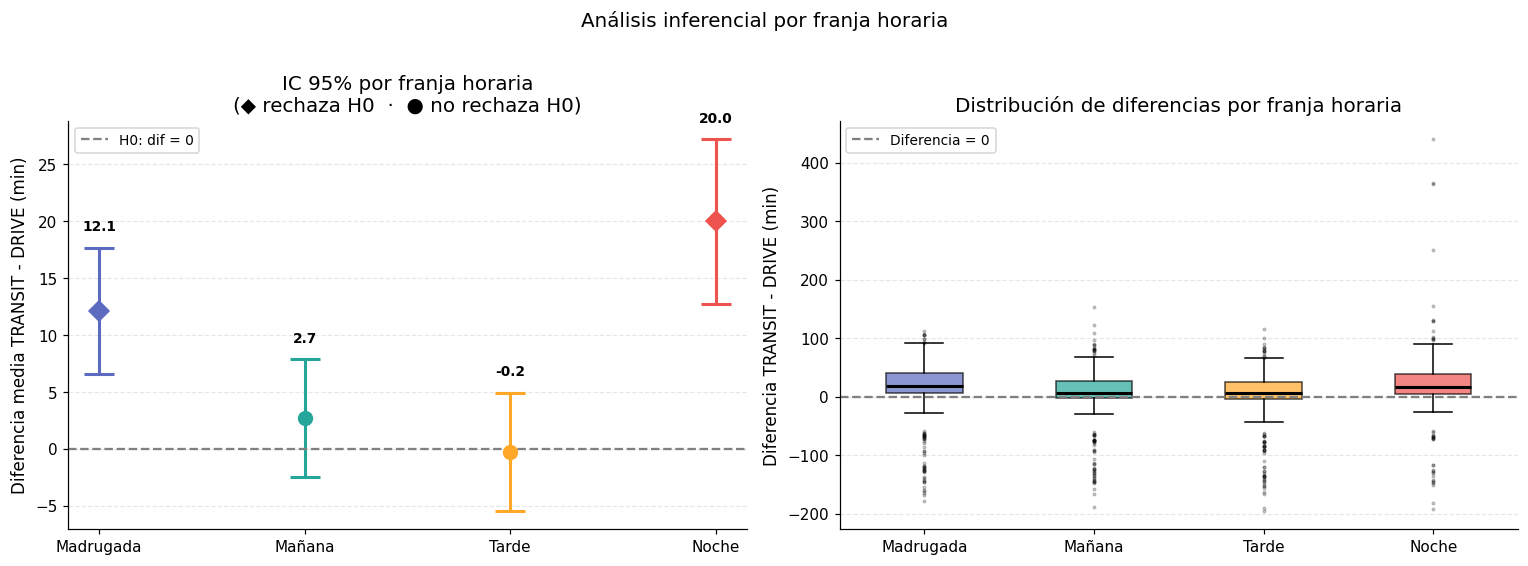

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, (etiq, row) in enumerate(df_f.iterrows()):
 med = row['Media(min)']
 lo = med - row['IC_inf']
 hi = row['IC_sup'] - med
 sig = row['Decision'] == 'Rechaza H0'
 ax.errorbar(i, med, yerr=[[lo], [hi]],
 fmt='D' if sig else 'o', color=COLORES_F[i],
 markersize=9, capsize=10, capthick=2, linewidth=2)
 ax.text(i, row['IC_sup'] + 1.5, f'{med:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='H0: dif = 0')
ax.set_xticks(range(4))
ax.set_xticklabels(ETIQ_F, fontsize=10)
ax.set_ylabel('Diferencia media TRANSIT - DRIVE (min)')
ax.set_title('IC 95% por franja horaria\n(◆ rechaza H0 · ● no rechaza H0)')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = axes[1]
grupos_f = [pareado[pareado['franja'] == f]['diferencia'].values for f in FRANJAS_ORD]
bp = ax2.boxplot(grupos_f, patch_artist=True,
 medianprops=dict(color='black', linewidth=2),
 flierprops=dict(marker='.', alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], COLORES_F):
 patch.set_facecolor(color)
 patch.set_alpha(0.7)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Diferencia = 0')
ax2.set_xticklabels(ETIQ_F, fontsize=10)
ax2.set_ylabel('Diferencia TRANSIT - DRIVE (min)')
ax2.set_title('Distribución de diferencias por franja horaria')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Análisis inferencial por franja horaria', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Conclusion — Seccion 6: Analisis por franja horaria

| Franja | Media dif. | IC 95 % | p-valor | Decision |
|---|---|---|---|---|
| Madrugada (00-06 h) | +12,1 min | [6,6 ; 17,7] | $1{,}02 \times 10^{-5}$ | RECHAZA $H_0$ |
| Manana (07-12 h) | +2,7 min | [−2,5 ; 7,9] | 0,152 | No rechaza $H_0$ |
| Tarde (13-18 h) | −0,2 min | [−5,4 ; 4,9] | 0,538 | No rechaza $H_0$ |
| Noche (19-23 h) | +20,0 min | [12,8 ; 27,2] | $5{,}57 \times 10^{-8}$ | RECHAZA $H_0$ |

Diferencia significativa ($p < 0{,}05$): **Madrugada** y **Noche**.
Sin diferencia significativa: Manana y Tarde — la congestion diurna nivela ambos modos.

### Interpretación por franja horaria

El análisis desagregado por franja horaria revela que **la ventaja del transporte privado no es uniforme a lo largo del día**. Se distinguen dos patrones:

**Franjas con diferencia estadísticamente significativa ($p < 0{,}05$):**

- **Noche (19-23 h):** diferencia media de **+20,0 min** a favor del privado. Es la franja donde el transporte público resulta más lento, posiblemente por la menor frecuencia de servicio y la mayor fluidez del tráfico rodado.
- **Madrugada (00-06 h):** diferencia de **+12,1 min**, también significativa. El tráfico prácticamente desaparece, pero el transporte público presenta amplios intervalos de paso que elevan el tiempo total.

**Franjas sin diferencia estadísticamente significativa ($p \geq 0{,}05$):**

- **Mañana (07-12 h)** y **Tarde (13-18 h):** las diferencias (+2,7 min y −0,25 min) no son distinguibles de cero. En hora punta la congestión del tráfico erosiona la ventaja del coche, equiparando ambos modos.

> Este resultado sugiere que el transporte público es una alternativa **competitiva en tiempo** durante los picos de tráfico diurno, mientras que el privado recupera su ventaja cuando las calles están despejadas.

---
## 7. Análisis por distancia del trayecto

Dividimos los trayectos en tres rangos de distancia para comprobar si la ventaja del transporte privado es mayor en trayectos cortos, medios o largos.

| Rango | Distancia |
|---|---|
| Corta | ≤ 20 km |
| Media | 20 – 40 km |
| Larga | > 40 km |

En cada rango: $H_0: \mu_d = 0$ vs $H_1: \mu_d > 0$ (contraste unilateral derecho, $\alpha = 0.05$, varianza desconocida → $t_{n-1}$).

In [ ]:
alpha_sub = 0.05

# Añadir distancia_km desde los datos DRIVE originales
dist_ref = (
 df[df['modo_transporte'] == 'DRIVE']
 [['origen', 'destino', 'hora_salida', 'distancia_km']]
 .drop_duplicates()
)
pareado_r = pareado.merge(dist_ref, on=['origen', 'destino', 'hora_salida'], how='left')

def rango_km(km):
 if km <= 20: return 'Corta'
 elif km <= 40: return 'Media'
 else: return 'Larga'

RANGOS_ORD = ['Corta', 'Media', 'Larga']
COLORES_R = ['#4CAF50', '#FF9800', '#F44336']
pareado_r['rango'] = pareado_r['distancia_km'].apply(rango_km)

print('Distribución por rango de distancia:')
resumen_r = pareado_r.groupby('rango').agg(
 N=('diferencia', 'count'),
 Dist_media_km=('distancia_km', 'mean'),
 Media_dif_min=('diferencia', 'mean')
).reindex(RANGOS_ORD).round(2)
print(resumen_r)
print()

filas_r = []
for rango in RANGOS_ORD:
 d_sub = pareado_r[pareado_r['rango'] == rango]['diferencia'].values
 n_sub = len(d_sub)
 if n_sub >= 2:
  dbar = d_sub.mean()
  sd_sub = d_sub.std(ddof=1)
  ee_sub = sd_sub / np.sqrt(n_sub)
  gl_sub = n_sub - 1
  tc_ic = stats.t.ppf(1 - alpha_sub / 2, df=gl_sub)
  ic_i = dbar - tc_ic * ee_sub
  ic_s = dbar + tc_ic * ee_sub
  t_sub = dbar / ee_sub
  tc_t = stats.t.ppf(1 - alpha_sub, df=gl_sub)
  pval = float(stats.t.sf(t_sub, df=gl_sub))
  filas_r.append({
   'Rango': rango,
   'n': n_sub,
   'Media(min)': round(dbar, 2),
   'Sd': round(sd_sub, 2),
   'IC_inf': round(ic_i, 2),
   'IC_sup': round(ic_s, 2),
   't_obs': round(t_sub, 3),
   't_crit': round(tc_t, 3),
   'p_valor': f'{pval:.2e}',
   'Decision': 'Rechaza H0' if t_sub > tc_t else 'No rechaza H0',
  })

df_r = pd.DataFrame(filas_r).set_index('Rango')
print('IC 95% Y CONTRASTE POR RANGO DE DISTANCIA')
print(f'H0: mu_d = 0 vs H1: mu_d > 0 (unilateral derecho, alfa={alpha_sub})')
print()
df_r

Distribución por rango de distancia:
         N  Dist_media_km  Media_dif_min
rango                                   
Corta  706          12.10          19.32
Media  297          25.52          24.49
Larga  388         289.97         -25.05

IC 95% Y CONTRASTE POR RANGO DE DISTANCIA
H0: mu_d = 0  vs  H1: mu_d > 0  (unilateral derecho, alfa=0.05)



,n,Media(min),Sd,IC_inf,IC_sup,t_obs,t_crit,p_valor,Decision
Rango,,,,,,,,,
Corta,706,19.32,20.13,17.84,20.81,25.503,1.647,1.85e-102,Rechaza H0
Media,297,24.49,26.96,21.42,27.57,15.659,1.650,5.59e-41,Rechaza H0
Larga,388,-25.05,88.63,-33.90,-16.20,-5.567,1.649,1.00e+00,No rechaza H0


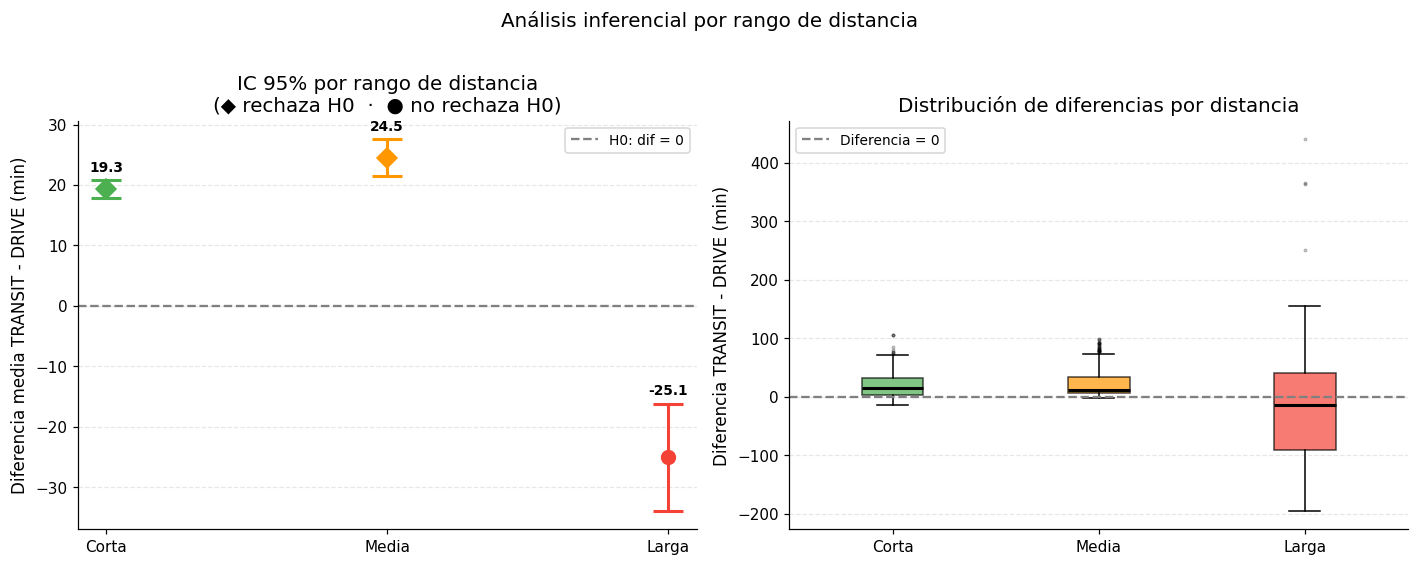

In [ ]:
rangos_pres = df_r.index.tolist()
colores_r_pres = [COLORES_R[RANGOS_ORD.index(r)] for r in rangos_pres]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, (rango, row) in enumerate(df_r.iterrows()):
 med = row['Media(min)']
 lo = med - row['IC_inf']
 hi = row['IC_sup'] - med
 sig = row['Decision'] == 'Rechaza H0'
 ax.errorbar(i, med, yerr=[[lo], [hi]],
 fmt='D' if sig else 'o', color=colores_r_pres[i],
 markersize=9, capsize=10, capthick=2, linewidth=2)
 ax.text(i, row['IC_sup'] + 1.5, f'{med:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='H0: dif = 0')
ax.set_xticks(range(len(rangos_pres)))
ax.set_xticklabels(rangos_pres, fontsize=10)
ax.set_ylabel('Diferencia media TRANSIT - DRIVE (min)')
ax.set_title('IC 95% por rango de distancia\n(◆ rechaza H0 · ● no rechaza H0)')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = axes[1]
grupos_r = [pareado_r[pareado_r['rango'] == r]['diferencia'].values for r in rangos_pres]
bp = ax2.boxplot(grupos_r, patch_artist=True,
 medianprops=dict(color='black', linewidth=2),
 flierprops=dict(marker='.', alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], colores_r_pres):
 patch.set_facecolor(color)
 patch.set_alpha(0.7)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Diferencia = 0')
ax2.set_xticklabels(rangos_pres, fontsize=10)
ax2.set_ylabel('Diferencia TRANSIT - DRIVE (min)')
ax2.set_title('Distribución de diferencias por distancia')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Análisis inferencial por rango de distancia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Conclusion — Seccion 7: Analisis por rango de distancia

| Rango | Media dif. | IC 95 % | p-valor | Decision |
|---|---|---|---|---|
| Corta (≤ 20 km) | +19,3 min | [17,8 ; 20,8] | $1{,}85 \times 10^{-102}$ | RECHAZA $H_0$ — publico mas lento |
| Media (20–40 km) | +24,5 min | [21,4 ; 27,6] | $5{,}59 \times 10^{-41}$ | RECHAZA $H_0$ — publico mas lento |
| Larga (> 40 km) | −25,1 min | [−33,9 ; −16,2] | 1,00 | No rechaza* — publico mas rapido |

\* El IC [−33,9 ; −16,2] **no contiene el 0**: diferencia real en sentido contrario a $H_1$. Un contraste bilateral lo detectaria formalmente.

### Interpretación por rango de distancia

La distancia del trayecto introduce una **inversión en el sentido de la diferencia** que merece atención especial:

**Trayectos cortos (≤ 20 km) y medios (20-40 km):**
- El transporte público tarda significativamente más: **+19,3 min** y **+24,5 min** respectivamente, con intervalos de confianza estrechos y bien alejados de cero.
- Los transbordos, esperas y la menor velocidad comercial penalizan al transporte público en distancias urbanas y periurbanas.

**Trayectos largos (> 40 km):**
- La diferencia media es **−25,1 min**: el transporte público resulta *más rápido* en este grupo.
- El IC 95 % es **[−33,9 ; −16,2]**, que no contiene el 0, por lo que la diferencia es estadísticamente real, aunque en **sentido contrario** al contemplado por $H_1$.
- Una explicación plausible es que los trayectos largos en Madrid incluyen servicios de alta capacidad como Cercanías o la línea 8 al aeropuerto, cuya velocidad media supera a la del coche con tráfico.

> **Nota:** el contraste planteado era unilateral derecho ($H_1: \mu_d > 0$). Para detectar formalmente la inversión en trayectos largos se requeriría un **contraste bilateral** o un $H_1$ en sentido contrario.

---
## 8. Conclusiones del análisis inferencial

Se sintetizan los resultados de los cuatro análisis realizados.
Para cada uno se indica la decisión al nivel de significación $\alpha = 0.05$,
el intervalo de confianza al 95% y el p-valor observado.

> **Recordatorio de lectura:** $H_0$ nunca se acepta — solo se rechaza o no se rechaza.
> Un p-valor alto no demuestra que los modos sean iguales, solo que los datos no aportan
> evidencia suficiente para concluir que son distintos.

### Resumen general del analisis inferencial

**$n = 1\,391$ pares ruta-hora · Nivel de significacion $\alpha = 0{,}05$**

#### 1. Intervalos de confianza al 95 %

| Parametro | IC 95 % | ¿Contiene el 0? |
|---|---|---|
| $\mu_{\text{DRIVE}}$ | [60,03 ; 69,22] min | — |
| $\mu_{\text{TRANSIT}}$ | [68,73 ; 76,62] min | — |
| **$\mu_{\text{dif}}$ (T − D)** | **[5,18 ; 10,92] min** | **No → diferencia real** |

#### 2. Contraste T de Student Pareada ($H_0$: $\mu_d = 0$ vs $H_1$: $\mu_d > 0$)

| $t$ observado | $t$ critico | p-valor | Decision |
|---|---|---|---|
| 5,5036 | 1,6460 | $2{,}21 \times 10^{-8}$ | **RECHAZA $H_0$** |

#### 3. Por franja horaria

| Franja | Media dif. | IC 95 % | Decision |
|---|---|---|---|
| Madrugada | +12,1 min | [6,6 ; 17,7] | RECHAZA $H_0$ |
| Manana | +2,7 min | [−2,5 ; 7,9] | No rechaza $H_0$ |
| Tarde | −0,2 min | [−5,4 ; 4,9] | No rechaza $H_0$ |
| Noche | +20,0 min | [12,8 ; 27,2] | RECHAZA $H_0$ |

#### 4. Por rango de distancia

| Rango | Media dif. | IC 95 % | Decision |
|---|---|---|---|
| Corta (≤ 20 km) | +19,3 min | [17,8 ; 20,8] | RECHAZA $H_0$ — publico mas lento |
| Media (20–40 km) | +24,5 min | [21,4 ; 27,6] | RECHAZA $H_0$ — publico mas lento |
| Larga (> 40 km) | −25,1 min | [−33,9 ; −16,2] | No rechaza* — publico mas rapido |

\* IC no contiene el 0: diferencia real en sentido contrario a $H_1$.

#### Conclusion

Con $n = 1\,391$ pares y $\alpha = 0{,}05$, se rechaza $H_0$: el transporte publico tarda significativamente mas que el privado (IC 95 %: [5,2 ; 10,9] min).
La diferencia es maxima de noche (+20,0 min) y desaparece en las franjas diurnas donde el trafico nivela ambos modos.
En trayectos largos (> 40 km) la tendencia se invierte: el publico resulta mas rapido.

---
## Síntesis narrativa del análisis inferencial

El análisis sobre los **1 391 pares ruta-hora** ofrece una imagen matizada de la comparación entre transporte privado y público en Madrid:

### Resultado global
Con $\alpha = 0{,}05$ y un p-valor de $2{,}21 \times 10^{-8}$, se rechaza la hipótesis nula. El transporte público tarda, en promedio, **8,0 minutos más** que el privado (IC 95 %: [5,2 ; 10,9] min). La diferencia es estadísticamente sólida gracias al gran tamaño muestral, que garantiza la validez del TCL.

### Matices por franja horaria
La diferencia no es constante a lo largo del día. Durante la **mañana y la tarde**, la congestión del tráfico nivela ambos modos y la diferencia no es significativa. **Por la noche y en madrugada**, cuando las calles están despejadas pero el servicio público reduce su frecuencia, el privado recupera una ventaja clara de 12-20 minutos.

### Matices por distancia
En **trayectos cortos y medios** (≤ 40 km), el privado es sistemáticamente más rápido. En **trayectos largos** (> 40 km), la tendencia se invierte: el público resulta más rápido, probablemente gracias a infraestructuras de alta capacidad (Cercanías, metro al aeropuerto).

### Consideraciones finales
- Rechazar $H_0$ no implica que la diferencia sea siempre relevante en la práctica: en hora punta o en trayectos largos, el transporte público es una alternativa competitiva en tiempo.
- El riesgo de error de tipo I está controlado al 5 %. El riesgo de error de tipo II es muy bajo dado el tamaño muestral ($n = 1\,391$).
- Los resultados son válidos para el contexto geográfico y temporal de los datos y pueden no generalizarse a otras ciudades o períodos.